<a href="https://colab.research.google.com/github/Bootcamp-DA-P3/Proyecto-3-flujo-de-datos-de-SQL-a-Python-de-Antony-Miguel-y-Carol/blob/main/notebooks/Proy_3_SQL_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto 3 - SQL a Python**
## **Procesamiento y limpieza de datos con Python**

En este proyecto cogemos información de un fichero .csv que hemos creado en un DataFrame con Python después de haberlo exportado con una SQL de una Base de Datos de MySQL Workbench.

El objetivo es hacer una limpieza más profunda de los datos después de haberlos filtrado en SQL.
  
Finalmente se mostrarán unas gráficas con el estudio sobre la calidad de los datos.

## 1. Importación.

1. Cargamos la información desde un fichero .csv y la agregamos a un DataFrame.

In [2]:
import io
import pandas as pd
from google.colab import files

# 1. Muestra el botón para subir el archivo
uploaded = files.upload()

# 2. Verifica si se subió un archivo y lo carga en un DataFrame de Pandas
for filename in uploaded.keys():
    if filename.endswith(".csv"):
        df = pd.read_csv(io.BytesIO(uploaded[filename]))
        print(f"\n¡Archivo '{filename}' cargado con éxito!")
        display(df.head())  # Muestra las primeras filas
    else:
        print(
            "Por favor, selecciona un archivo con extensión .csv"
        )

Saving df3_vendedores_popularidad.csv to df3_vendedores_popularidad.csv

¡Archivo 'df3_vendedores_popularidad.csv' cargado con éxito!


,seller_city_clean,seller_state_clean,seller_id,product_id,product_category_name,unidades_vendidas_producto,pedidos_distintos_producto,ingreso_total_producto,ranking_producto_en_vendedor
0,sao paulo,sp,955fee9216a65b617aa5c0531780ce60,aca2eb7d00ea1a7b8ebd4e68314663af,moveis_decoracao,527,431,37608.90,1
1,sao jose do rio preto,sp,1f50f920176fa81dab994f9023523100,422879e10f46682990de24d770e7f83d,ferramentas_jardim,484,352,26577.22,1
2,ibitinga,sp,4a3ca9315b744ce9f8e9374361493884,99a4788cb24856965c36a24e339b6058,cama_mesa_banho,482,461,42518.40,1
3,sao jose do rio preto,sp,1f50f920176fa81dab994f9023523100,389d119b48cf3043d311335e499d9c6b,ferramentas_jardim,392,311,21440.59,2
4,sao jose do rio preto,sp,1f50f920176fa81dab994f9023523100,368c6c730842d78016ad823897a372db,ferramentas_jardim,388,291,21056.80,3


In [ ]:
# Generamos una copia para comparar al final los cambios realizados.
df_old = df.copy()

## 2. Exploración inicial.

1. Vemos que información trae el dataframe para su estudio.

In [ ]:
#Miguel, Anthony, Jesus
# Detalle general del pd.DataFrame (Números de datos, tipos de datos, valores nulos)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  object 
 1   Item              9667 non-null   object 
 2   Quantity          9862 non-null   object 
 3   Price Per Unit    9821 non-null   object 
 4   Total Spent       9827 non-null   object 
 5   Entregado         10000 non-null  float64
 6   Payment Method    7421 non-null   object 
 7   Location          6735 non-null   object 
 8   Transaction Date  9841 non-null   object 
dtypes: float64(1), object(8)
memory usage: 703.3+ KB


In [ ]:
#Miguel, Anthony, Jesus
# Número de filas y columnas.
df.shape

(10000, 9)

In [ ]:
#Miguel, Anthony, Jesus
# Lista las columnas del dataframe.
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Entregado', 'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

In [ ]:
#Miguel, Anthony, Jesus
# Vemos que tipo de dato tenemos en cada columna
df.dtypes

,0
Transaction ID,object
Item,object
Quantity,object
Price Per Unit,object
Total Spent,object
Entregado,float64
Payment Method,object
Location,object
Transaction Date,object


2. Valores iniciales y finales del DataFrame.

In [ ]:
#Miguel, Anthony, Jesus
# Valores inicales (5 primeras filas)
df.head(5)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Entregado,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,0.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,0.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,0.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,0.0,Digital Wallet,In-store,2023-06-11


In [ ]:
#Miguel, Anthony, Jesus
# Valores finales (5 últimas filas)
df.tail(5)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Entregado,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2.0,4.0,0.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,0.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,0.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,0.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,36.0,Cash,In-store,2023-11-07


## 3. Diagnóstico de datos.

1. Hacemos un análisis previo de los datos del dataframe para evaluar que acciones tomar.

In [ ]:
#Miguel, Anthony, Jesus
#Diagnostico de variables numericas y estadisticas.
df.describe()

,Entregado
count,10000.000000
mean,5.382900
std,13.619368
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,100.000000


In [ ]:
#Miguel, Anthony, Jesus
# Diagnostico de valones nulos.
df.isna().sum()

,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Entregado,0
Payment Method,2579
Location,3265
Transaction Date,159


In [ ]:
#Miguel, Anthony, Jesus
# Diagnostico de registros duplicados.
df.duplicated().sum()

np.int64(0)

## 4. Limpieza de datos.

1. Revisando el stock, sabemos que los valores no válidos en la columna "Item" han de cambiarse por los siguientes.


| Valor previo | Valor nuevo |
| --- | --- |
| | Coffee |
| ERROR | Sandwich |
| UNKNOWN | Cookie |

In [ ]:
#Miguel
# Cambiamos los valores no válidos de la columna "Item".
df['Item'] = df['Item'].replace('', 'Coffee')
df['Item'] = df['Item'].fillna('Coffee')
df['Item'] = df['Item'].replace('ERROR', 'Sandwich')
df['Item'] = df['Item'].replace('UNKNOWN', 'Cookie')

2. Eliminación de los errores de las columnas "Quantity", "Price Per Unit", "Total Spent".  
Se tiene que: "Total Spent" = "Quantity" x "Price Per Unit". A partir de esto podremos obtener muchos valores.  
Dado que hay varios tipos de valores de texto y queremos que en estas columnas aparezcan solo números, con el siguien código vamos forzar a convertir todos los valores a número y si no se puede, dejar vacío.

In [ ]:
#Jesus
import numpy as np

#Columnas que vamos a revisar
columnas = ["Quantity", "Price Per Unit", "Total Spent"]

#Conversión a número
df[columnas] = df[columnas].apply(pd.to_numeric,errors="coerce")

Observamos que ya se reconocen como números los datos de estas columnas.

In [ ]:
#Jesus
print(df.dtypes)

Transaction ID       object
Item                 object
Quantity            float64
Price Per Unit      float64
Total Spent         float64
Entregado           float64
Payment Method       object
Location             object
Transaction Date     object
dtype: object


In [ ]:
#Jesus
df.isnull().sum()

,0
Transaction ID,0
Item,0
Quantity,479
Price Per Unit,533
Total Spent,502
Entregado,0
Payment Method,2579
Location,3265
Transaction Date,159


In [ ]:
#Jesus
vacios1 = df["Quantity"].isna()

df.loc[vacios1, "Quantity"] = (
    df.loc[vacios1, "Total Spent"] /
    df.loc[vacios1, "Price Per Unit"]
)

In [ ]:
#Jesus
print(df["Quantity"].isnull().sum())

38


Se reduce considerablemente el número de vacíos de la columna "Quantity" pero, ¿Por qué siguen apareciendo valores vacíos?

In [ ]:
#Jesus
vacios2=df["Quantity"].isna()
df.loc[vacios2, ["Item","Quantity", "Price Per Unit", "Total Spent"]]

,Item,Quantity,Price Per Unit,Total Spent
236,Salad,NaN,5.0,NaN
278,Juice,NaN,3.0,NaN
629,Cake,NaN,NaN,12.0
641,Juice,NaN,3.0,NaN
738,Sandwich,NaN,4.0,NaN
912,Sandwich,NaN,NaN,20.0
1008,Tea,NaN,NaN,3.0
1436,Tea,NaN,NaN,6.0
1482,Smoothie,NaN,NaN,16.0
2330,Salad,NaN,NaN,5.0


Se observa que el problema esá en que no ha podido hacer la cuenta porque también falta el valor de alguna de las otras dos columnas.

Estos valores no hay ninguna forma exacta de recuperarlos. Vamos a completar estos vacíos con el valor medio de esta columna (redondeado).

In [ ]:
#Jesus
media = df['Quantity'].mean()
mediaQ = round(media)
round(mediaQ)

3

In [ ]:
#Jesus
df['Quantity'] = df['Quantity'].fillna(mediaQ)

Ahora vamos a rellenar los vacíos de las columnas "Price Per Unit" y "Total Spent" siguiendo con la misma idea que en el caso anterior.

In [ ]:
#Jesus
# Filas donde Price Per Unit y Total Spent están ambos vacíos
vacios3 = (
    df["Price Per Unit"].isna() &
    df["Total Spent"].isna()
)

# Asignar a Price Per Unit (vacíos) el valor medio de su columna
df.loc[vacios3, "Price Per Unit"] = round(df['Price Per Unit'].mean())

In [ ]:
#Jesus
df.loc[vacios3, ["Price Per Unit","Total Spent"]].head()

,Price Per Unit,Total Spent
65,3.0,NaN
1674,3.0,NaN
1761,3.0,NaN
2229,3.0,NaN
2289,3.0,NaN


In [ ]:
#Jesus
for i in range(len(df)):

    if pd.isna(df.loc[i, 'Price Per Unit']):
        df.loc[i, 'Price Per Unit'] = df.loc[i, 'Total Spent'] / df.loc[i, 'Quantity']

    elif pd.isna(df.loc[i, 'Total Spent']):
        df.loc[i, 'Total Spent'] = df.loc[i, 'Quantity'] * df.loc[i, 'Price Per Unit']

Comprobamos los resultados

In [ ]:
#Jesus
print(df['Price Per Unit'].isna().sum())
print(df['Total Spent'].isna().sum())

0
0


In [ ]:
#Jesus
df.loc[vacios3, ["Quantity","Price Per Unit","Total Spent"]].head()

,Quantity,Price Per Unit,Total Spent
65,3.0,3.0,9.0
1674,2.0,3.0,6.0
1761,4.0,3.0,12.0
2229,2.0,3.0,6.0
2289,4.0,3.0,12.0


Ya están las tres columnas completas, sin errores ni celdas vacías y todo parece funcionar bien.

3. Limpieza de datos de las columnas "Payment Method", "Location" y "Transaction Date".

Agregamos una columna llamada "Devolucion" para registrar el cambio de todas las personas pagaron con cash.

In [ ]:
#Anthony
# Crear columna Devolucion
df['Devolucion'] = df.apply(lambda x: max(0, x['Entregado'] - x['Total Spent'])
  if x['Payment Method'] == 'Cash'
     else 0, axis=1)
display(df[['Total Spent', 'Entregado', 'Payment Method', 'Devolucion']])

,Total Spent,Entregado,Payment Method,Devolucion
0,4.0,0.0,Credit Card,0.0
1,12.0,12.0,Cash,0.0
2,4.0,0.0,Credit Card,0.0
3,10.0,0.0,UNKNOWN,0.0
4,4.0,0.0,Digital Wallet,0.0
...,...,...,...,...
9995,4.0,0.0,NaN,0.0
9996,3.0,0.0,Digital Wallet,0.0
9997,8.0,0.0,Digital Wallet,0.0
9998,3.0,0.0,Digital Wallet,0.0


Se reeamplaza en la colunna "Payment Method" todo los resultados que me salieran error,unknown y vacios con la palabra online para tener un orden en el metodo de pago.

In [ ]:
#Anthony
df['Payment Method'] = df['Payment Method'].replace(
['UNKNOWN', 'ERROR', ''],
'ONLINE'
)

df['Payment Method'] = df['Payment Method'].fillna('ONLINE')
display(df)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Entregado,Payment Method,Location,Transaction Date,Devolucion
0,TXN_1961373,Coffee,2.0,2.0,4.0,0.0,Credit Card,Takeaway,2023-09-08,0.0
1,TXN_4977031,Cake,4.0,3.0,12.0,12.0,Cash,In-store,2023-05-16,0.0
2,TXN_4271903,Cookie,4.0,1.0,4.0,0.0,Credit Card,In-store,2023-07-19,0.0
3,TXN_7034554,Salad,2.0,5.0,10.0,0.0,ONLINE,UNKNOWN,2023-04-27,0.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,0.0,Digital Wallet,In-store,2023-06-11,0.0
...,...,...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,0.0,ONLINE,UNKNOWN,2023-08-30,0.0
9996,TXN_9659401,Coffee,3.0,1.0,3.0,0.0,Digital Wallet,NaN,2023-06-02,0.0
9997,TXN_5255387,Coffee,4.0,2.0,8.0,0.0,Digital Wallet,NaN,2023-03-02,0.0
9998,TXN_7695629,Cookie,3.0,1.0,3.0,0.0,Digital Wallet,NaN,2023-12-02,0.0


Se reemplazo la columna "Location" todo los resultados error,unknown y vacios con la palabra desconocido.

In [ ]:
#Anthony
# Convertir a texto para detectar variantes
df['Location'] = df['Location'].astype(str)

# Reemplazar valores problemáticos
df['Location'] = df['Location'].replace({
'UNKNOWN': 'Desconocido',
'unknown': 'Desconocido',
'ERROR': 'Desconocido',
'error': 'Desconocido',
'': 'Desconocido',
'nan': 'Desconocido',
'NaN': 'Desconocido'
})

# Rellenar nulos reales
df['Location'] = df['Location'].fillna('Desconocido')
display(df)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Entregado,Payment Method,Location,Transaction Date,Devolucion
0,TXN_1961373,Coffee,2.0,2.0,4.0,0.0,Credit Card,Takeaway,2023-09-08,0.0
1,TXN_4977031,Cake,4.0,3.0,12.0,12.0,Cash,In-store,2023-05-16,0.0
2,TXN_4271903,Cookie,4.0,1.0,4.0,0.0,Credit Card,In-store,2023-07-19,0.0
3,TXN_7034554,Salad,2.0,5.0,10.0,0.0,ONLINE,Desconocido,2023-04-27,0.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,0.0,Digital Wallet,In-store,2023-06-11,0.0
...,...,...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,0.0,ONLINE,Desconocido,2023-08-30,0.0
9996,TXN_9659401,Coffee,3.0,1.0,3.0,0.0,Digital Wallet,Desconocido,2023-06-02,0.0
9997,TXN_5255387,Coffee,4.0,2.0,8.0,0.0,Digital Wallet,Desconocido,2023-03-02,0.0
9998,TXN_7695629,Cookie,3.0,1.0,3.0,0.0,Digital Wallet,Desconocido,2023-12-02,0.0


Se reemplazaron la columna Transaction Date todo el resultado que me arrojen Unknown error y vacios por 0000-00-0

In [ ]:
#Anthony
# Reemplazar valores problemáticos
df['Transaction Date'] = df['Transaction Date'].replace(
['UNKNOWN', 'unknown', 'ERROR', 'error', ''],
'0000-00-00'
)

# Reemplazar valores nulos
df['Transaction Date'] = df['Transaction Date'].fillna('0000-00-00')
display(df)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Entregado,Payment Method,Location,Transaction Date,Devolucion
0,TXN_1961373,Coffee,2.0,2.0,4.0,0.0,Credit Card,Takeaway,2023-09-08,0.0
1,TXN_4977031,Cake,4.0,3.0,12.0,12.0,Cash,In-store,2023-05-16,0.0
2,TXN_4271903,Cookie,4.0,1.0,4.0,0.0,Credit Card,In-store,2023-07-19,0.0
3,TXN_7034554,Salad,2.0,5.0,10.0,0.0,ONLINE,Desconocido,2023-04-27,0.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,0.0,Digital Wallet,In-store,2023-06-11,0.0
...,...,...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,0.0,ONLINE,Desconocido,2023-08-30,0.0
9996,TXN_9659401,Coffee,3.0,1.0,3.0,0.0,Digital Wallet,Desconocido,2023-06-02,0.0
9997,TXN_5255387,Coffee,4.0,2.0,8.0,0.0,Digital Wallet,Desconocido,2023-03-02,0.0
9998,TXN_7695629,Cookie,3.0,1.0,3.0,0.0,Digital Wallet,Desconocido,2023-12-02,0.0


 ## 5. Validación.

1. Vamos a realizar una comprobación rápida de valores nulos entre el DataFrame original y el actual mediante una gráfica.

Dataframe Original

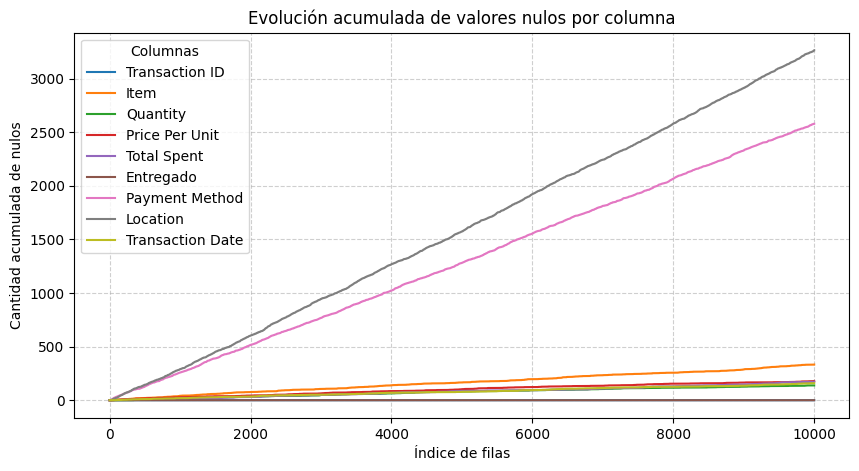

In [ ]:
#Miguel

import matplotlib.pyplot as plt

# Columnas que vamos a analizar
columnas = ['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Entregado', 'Payment Method', 'Location', 'Transaction Date']

# Creamos un DataFrame booleano (True si es nulo, False si no)
# Suma de forma acumulada a lo largo de los registros
nulos_acumulados = df_old[columnas].isna().cumsum()

# Crear la gráfica
plt.figure(figsize=(10, 5))
plt.plot(nulos_acumulados)

plt.title('Evolución acumulada de valores nulos por columna')
plt.xlabel('Índice de filas')
plt.ylabel('Cantidad acumulada de nulos')
plt.legend(columnas, title='Columnas')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Dataframe tras la limpieza.

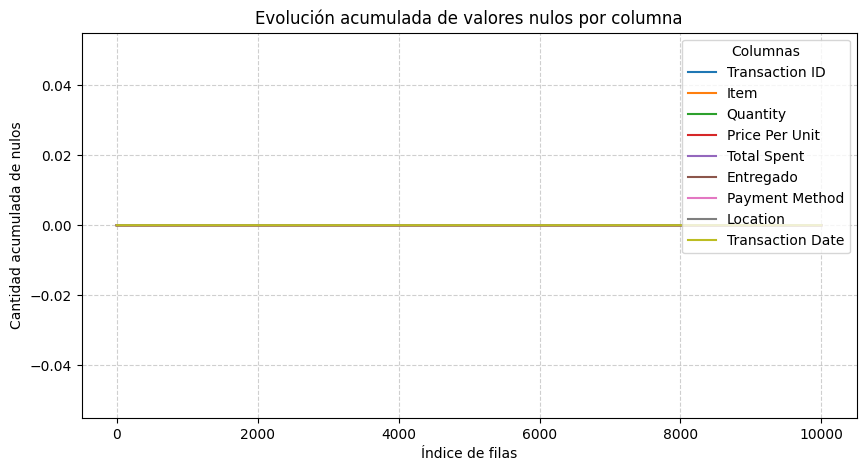

In [ ]:
#Miguel

# Columnas que vamos a analizar
columnas = ['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Entregado', 'Payment Method', 'Location', 'Transaction Date']

# Creamos un DataFrame booleano (True si es nulo, False si no)
# Suma de forma acumulada a lo largo de los registros
nulos_acumulados = df[columnas].isna().cumsum()

# Crear la gráfica
plt.figure(figsize=(10, 5))
plt.plot(nulos_acumulados)

plt.title('Evolución acumulada de valores nulos por columna')
plt.xlabel('Índice de filas')
plt.ylabel('Cantidad acumulada de nulos')
plt.legend(columnas, title='Columnas')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## Exportación del dataset limpio.

In [ ]:
#Miguel

# Importamos esta libreria para poder guardar el fichero en el ordenador desde el que se está ejecuntando y no en la nube del drive.
from google.colab import files

# Guardar el DataFrame temporalmente en el entorno de Colab
# (encoding='utf-8-sig' asegura que tildes y caracteres especiales se vean bien en Excel)
df.to_csv('datos_limpios.csv', index=False, encoding='utf-8-sig')

# Disparar la descarga en el navegador
files.download('datos_limpios.csv')

NameError: name 'df' is not defined